# The OpenSense radar-adjustment intercomparison, reproduced

Radar adjusted with commercial microwave links by the eight methods of OpenSense's
`radar_adjustment_intercomparison` (`mergeplg`), on OpenMRG (Gothenburg, JJA 2015) and
OpenRainER (Emilia-Romagna, JJA 2022), hourly, scored at gauges no method uses.
This notebook reads the tables written by `python projects/maps/radar_adjustment/src/run.py report`;
it does not recompute anything. See `README.md` for the pipeline and `results/report.md` for every table.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

RES = Path.cwd().parent / "results" if Path.cwd().name == "notebooks" else Path("projects/maps/radar_adjustment/results")
scores = pd.read_csv(RES / "scores.csv")
pd.set_option("display.precision", 3)
scores.groupby(["network", "version", "checks"]).size().rename("products").to_frame()

products
network    version checks            
openmrg    main    c0within         1
                   cc               9
                   default          9
                   mapping         10
                   nc               9
                   stations        10
                   vg5km            1
                   vgfit            1
           pinned  cc               9
                   default          9
                   nc               9
openrainer main    c0within         1
                   cc               9
                   default          9
                   mapping          4
                   nc               9
                   vg5km            1
                   vgfit            1
           pinned  cc               4
                   default          9
                   nc               4

## 1. Replication

The prepared inputs reproduce the published radar row exactly; then each method with the
commit the OpenSense repository pins (`pinned`) and with mergeplg main (`main`).

In [2]:
import sys
sys.path.insert(0, str(RES.parent / "src"))
from radar_adjustment.report import PUBLISHED_OPENMRG
ours = scores[(scores.network == "openmrg") & (scores.checks == "default")].pivot_table(
    index="product", columns="version", values=["rmse", "pcc", "pbias"])
pub = PUBLISHED_OPENMRG.set_index("product")[["rmse", "pcc", "pbias"]]
pub.columns = pd.MultiIndex.from_product([pub.columns, ["published"]])
pd.concat([pub, ours], axis=1).sort_index(axis=1).reindex(PUBLISHED_OPENMRG["product"])

pbias                      pcc                    rmse         \
             main  pinned published   main pinned published   main pinned   
product                                                                     
radar     -18.815 -18.815   -18.815  0.552  0.552     0.552  1.440  1.440   
add_p_idw -10.179 -10.702   -10.178  0.683  0.693     0.683  1.306  1.277   
add_p_ok  -10.313 -10.313   -10.313  0.696  0.696     0.696  1.267  1.267   
add_b_ok  -10.389 -12.717   -10.388  0.697  0.695     0.697  1.266  1.267   
ked_p     -11.277 -11.277   -11.278  0.687  0.687     0.687  1.290  1.290   
ked_b     -11.351 -13.383   -11.337  0.687  0.686     0.688  1.290  1.289   
mul_p_idw  -6.684  -7.287    -6.682  0.677  0.691     0.677  1.318  1.279   
mul_p_ok   -6.204  -6.204    -6.202  0.692  0.692     0.692  1.283  1.283   
mul_b_ok   -6.323  -9.244    -6.322  0.692  0.690     0.692  1.282  1.280   

                     
          published  
product              
radar         1.440  
add_p_idw     1.306  
add_p_ok      1.267  
add_b_ok      1.266  
ked_p         1.290  
ked_b         1.290  
mul_p_idw     1.318  
mul_p_ok      1.283  
mul_b_ok      1.282

## 2. Both networks, three range-check settings

In [3]:
main = scores[scores.checks.isin(["default", "cc", "nc"])]
main.pivot_table(index=["network", "product"], columns=["version", "checks"], values="rmse").round(3)

version                main                 pinned                
checks                   cc default      nc     cc default      nc
network    product                                                
openmrg    add_b_ok   1.295   1.266   1.272  1.295   1.267   1.270
           add_p_idw  1.325   1.306   1.308  1.312   1.277   1.280
           add_p_ok   1.296   1.267   1.273  1.296   1.267   1.273
           ked_b      1.306   1.290   1.301  1.304   1.289   1.297
           ked_p      1.306   1.290   1.301  1.306   1.290   1.301
           mul_b_ok   1.238   1.282   1.288  1.234   1.280   1.284
           mul_p_idw  1.268   1.318   1.314  1.263   1.279   1.291
           mul_p_ok   1.240   1.283   1.288  1.240   1.283   1.288
           radar      1.440   1.440   1.440  1.440   1.440   1.440
openrainer add_b_ok   3.408   3.186   3.904    NaN   3.189     NaN
           add_p_idw  3.412   3.189   3.956    NaN   3.143     NaN
           add_p_ok   3.419   3.196   4.016  3.419   3.196   4.016
           ked_b      3.268   3.080   5.101    NaN   3.111     NaN
           ked_p      3.268   3.082   5.318  3.268   3.082   5.318
           mul_b_ok   3.407   3.505  15.925    NaN   3.374     NaN
           mul_p_idw  3.470   3.581  15.453    NaN   4.269     NaN
           mul_p_ok   3.429   3.572  16.028  3.429   3.572  16.028
           radar      3.576   3.576   3.576  3.576   3.576   3.576

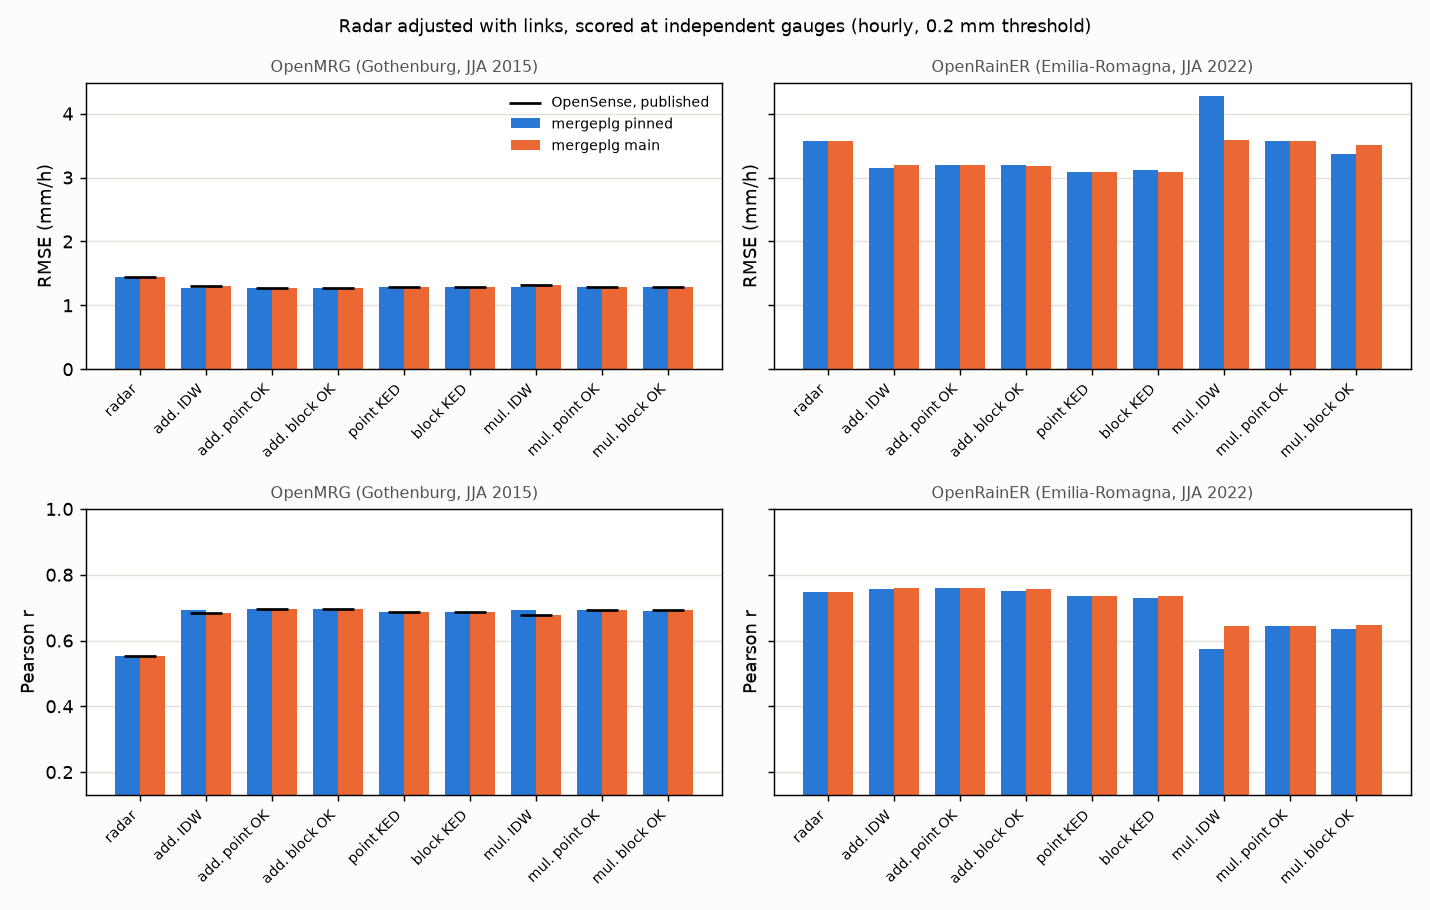

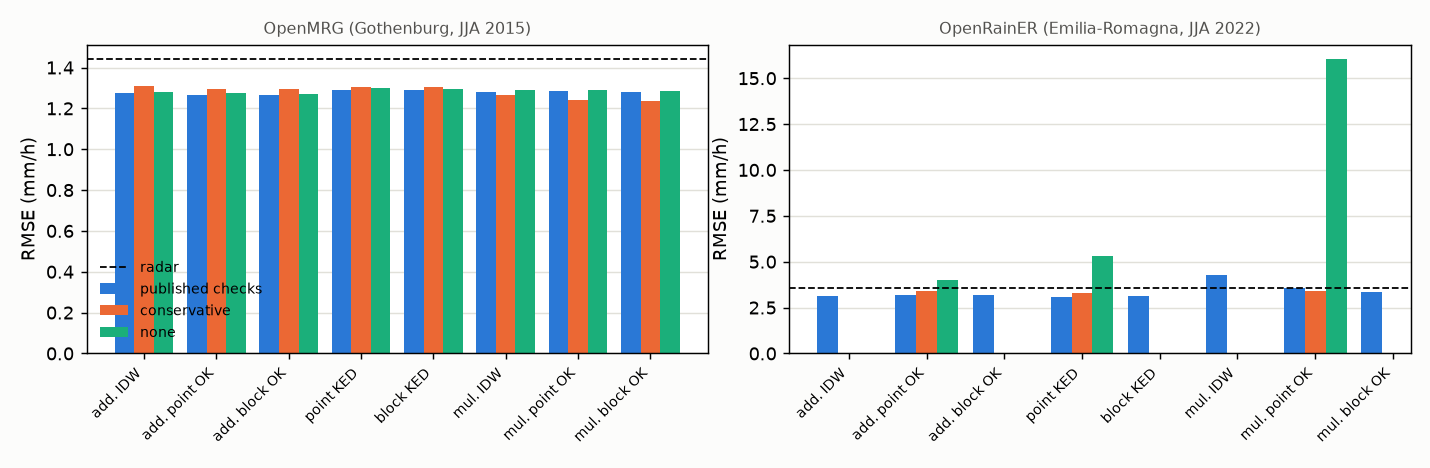

In [4]:
display(Image(RES / "figures" / "intercomparison.png"))
display(Image(RES / "figures" / "range_checks.png"))

## 3. Intensity and distance to the links

In [5]:
cls = pd.read_csv(RES / "scores_by_intensity.csv")
d = cls[(cls.version == "pinned") & (cls.checks == "default")]
d.pivot_table(index=["network", "product"], columns="class", values="rmse", sort=False).round(2)

class                 [0.2,2.5)  [2.5,10)  [10,50)   >=50
network    product                                       
openmrg    radar           0.81      2.94    10.26    NaN
           add_b_ok        0.60      2.53     8.66    NaN
           add_p_idw       0.61      2.55     8.60    NaN
           add_p_ok        0.61      2.53     8.54    NaN
           ked_b           0.61      2.55     8.87    NaN
           ked_p           0.62      2.56     8.73    NaN
           mul_b_ok        0.66      2.53     8.62    NaN
           mul_p_idw       0.64      2.55     8.78    NaN
           mul_p_ok        0.67      2.54     8.55    NaN
openrainer radar           3.18      6.54     8.55  25.45
           add_b_ok        2.05      4.81     8.77  26.58
           add_p_idw       2.07      4.79     8.60  26.53
           add_p_ok        2.09      4.88     8.55  26.27
           ked_b           1.32      3.85    10.46  34.82
           ked_p           1.36      3.90    10.25  34.54
           mul_b_ok        1.69      5.06    11.44  33.06
           mul_p_idw       1.93      7.35    13.95  32.60
           mul_p_ok        1.88      6.10    11.37  31.04

band                  0-2 km  2-5 km  5-10 km  10-20 km  >20 km
network    product                                             
openmrg    radar        1.44     NaN      NaN       NaN     NaN
           add_b_ok     1.27     NaN      NaN       NaN     NaN
           add_p_idw    1.28     NaN      NaN       NaN     NaN
           add_p_ok     1.27     NaN      NaN       NaN     NaN
           ked_b        1.29     NaN      NaN       NaN     NaN
           ked_p        1.29     NaN      NaN       NaN     NaN
           mul_b_ok     1.28     NaN      NaN       NaN     NaN
           mul_p_idw    1.28     NaN      NaN       NaN     NaN
           mul_p_ok     1.28     NaN      NaN       NaN     NaN
openrainer radar        3.48    3.57     3.74      3.51    3.39
           add_b_ok     2.86    3.21     3.32      3.28    3.16
           add_p_idw    2.83    3.15     3.30      3.20    3.10
           add_p_ok     2.87    3.18     3.34      3.29    3.18
           ked_b        2.74    3.08     3.17      3.36    3.06
           ked_p        2.70    3.03     3.15      3.35    3.03
           mul_b_ok     2.94    3.07     3.62      3.44    3.81
           mul_p_idw    3.25    3.22     4.47      5.46    3.91
           mul_p_ok     2.92    2.82     3.91      3.99    3.96

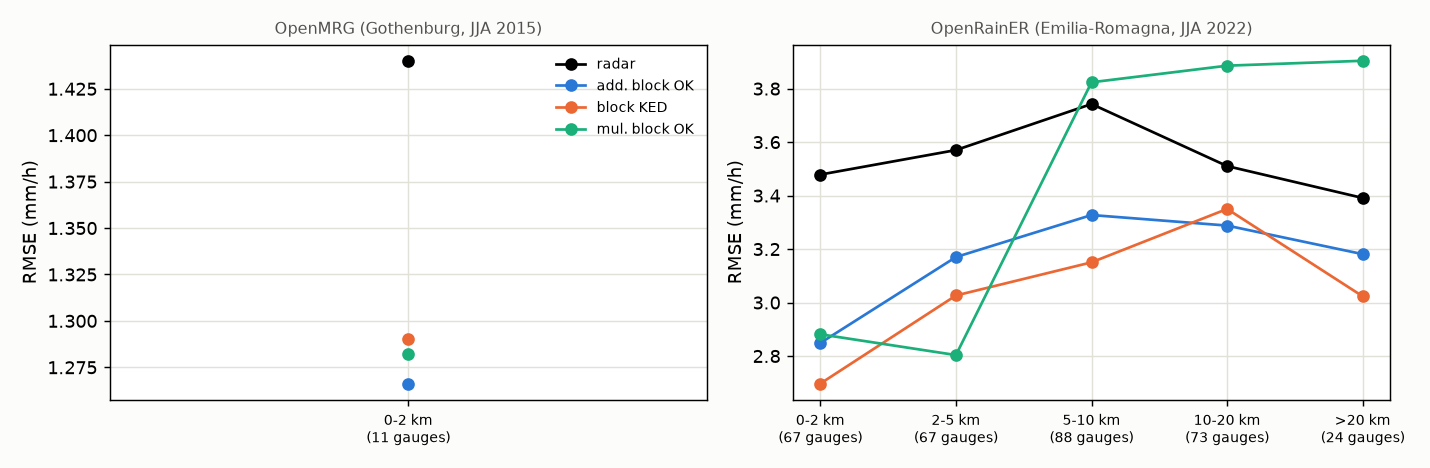

In [6]:
bands = pd.read_csv(RES / "scores_by_distance.csv")
d = bands[(bands.version == "pinned") & (bands.checks == "default")]
display(d.pivot_table(index=["network", "product"], columns="band", values="rmse", sort=False).round(2))
display(Image(RES / "figures" / "distance_to_links.png"))

## 4. Extensions

Weather stations as adjusters (Gothenburg), maps without radar, RADOLAN, the variogram,
and New York City.

In [7]:
ext = scores[scores.checks.isin(["mapping", "stations", "vg5km", "vgfit", "c0within"])]
ext.sort_values(["network", "rmse"])[["network", "checks", "product", "pcc", "rmse", "mae", "pbias", "n_pairs"]]

,network,checks,product,pcc,rmse,mae,pbias,n_pairs
56,openmrg,mapping,idw_map@pws,0.819,1.008,0.533,-13.748,2138
59,openmrg,mapping,okb_map@pws,0.806,1.030,0.546,-11.725,2187
62,openmrg,mapping,okp_map@pws,0.806,1.030,0.546,-11.725,2187
72,openmrg,stations,radolan@cml+pws,0.722,1.177,0.601,-10.173,2392
63,openmrg,mapping,radolan,0.717,1.187,0.601,-9.870,2400
69,openmrg,stations,ked_b@pws,0.727,1.214,0.638,-18.888,2106
67,openmrg,stations,add_p_idw@pws,0.726,1.218,0.647,-16.408,2086
73,openmrg,stations,radolan@pws,0.711,1.224,0.636,-21.381,2239
65,openmrg,stations,add_b_ok@pws,0.718,1.228,0.657,-16.101,2108
58,openmrg,mapping,okb_map@cml+pws,0.711,1.247,0.652,-10.706,2112


In [8]:
ny = RES / "newyork_asos.csv"
pd.read_csv(ny) if ny.exists() else "no New York run"

,product,pcc,cv,rmse,mae,pbias,ref_mean,est_mean,n_all,n_nan,n_pairs
0,radolan [pws],0.913,0.468,1.394,0.867,-5.219,2.958,2.804,663.0,0.0,581
1,idw_map [pws],0.899,0.478,1.499,0.926,-6.129,3.108,2.917,663.0,0.0,553
2,okb_map [pws],0.891,0.499,1.550,0.969,-4.780,3.091,2.943,663.0,0.0,556
3,idw_map [links rnn+pws],0.894,0.502,1.568,0.959,-8.382,3.080,2.822,663.0,0.0,558
4,radolan [links nearby+pws],0.894,0.525,1.589,0.972,-11.409,2.958,2.621,663.0,0.0,581
5,MRMS Pass 2,0.884,0.524,1.591,0.918,-3.607,3.031,2.922,663.0,0.0,567
6,okb_map [links rnn+pws],0.881,0.528,1.639,0.997,-8.103,3.069,2.820,663.0,0.0,560
7,radolan [links rnn+pws],0.885,0.550,1.654,0.975,-8.506,2.974,2.721,663.0,0.0,578
8,idw_map [links nearby+pws],0.886,0.517,1.664,1.009,-15.070,3.091,2.625,663.0,0.0,556
9,add_p_idw [pws],0.876,0.528,1.696,0.979,-12.055,3.131,2.753,663.0,0.0,549


![totals.png](../results/figures/totals.png)